In [237]:
#||Jai shree ram|| ||jai hanuman||

In [238]:
#! is used to run shell commands in the jupyter notebook.  
!pip install --upgrade openpyxl

In [246]:
#Importing pandas
import pandas as pd

In [248]:
#Here first we are reading the excel file.
df = pd.read_excel("C:\\Users\\Hp\\Downloads\\DataAnalyst_Assesment_Dataset.xlsx")

In [250]:
#Now we are converting the excel to csv file
df.to_csv("Bookingfile.csv", index=False)    #index=False avoids saving row numbers

In [252]:
df1 = pd.read_csv("Bookingfile.csv")
df1.tail()

,Booking ID,Customer ID,Customer Name,Booking Type,Booking Date,Status,Class Type,Instructor,Time Slot,Duration (mins),Price,Facility,Theme,Subscription Type,Service Name,Service Type,Customer Email,Customer Phone
995,b45c041f-6199-4a53-8841-1afd696d8c2d,ea4a4b7e-aad1-4ac5-9cb3-3a7c10a38819,Customer 996,Birthday Party,2025-05-04,Confirmed,NaN,NaN,NaN,NaN,104.83,Party Room,Princess,NaN,Party Room,Birthday Party,customer996@example.com,001-522-8955
996,633d1590-d9b2-4263-9b29-8589333c7a0a,10cd8264-a18b-4ee4-a035-27058df83238,Customer 997,Class,2025-05-02,Confirmed,Art,James Howard,NaN,NaN,119.02,NaN,NaN,NaN,Art,Class,customer997@example.com,NaN
997,c552c1b5-bb2e-46a5-b5c9-43101cf39133,623b4030-64c5-46ae-935f-fd9c3beea824,Customer 998,Facility,2025-04-04,Confirmed,NaN,NaN,17:00:00,120.0,172.84,Party Room,NaN,NaN,Party Room,Facility,customer998@example.com,001-391-4565
998,09fb0473-56cc-4624-9c5a-e9cd152acc41,e483e86a-cc2c-4a49-86ef-b7a0c1b6fd7b,Customer 999,Facility,2025-05-11,Pending,NaN,NaN,12:00:00,120.0,275.18,Party Room,NaN,NaN,Party Room,Facility,customer999@example.com,001-668-6307
999,552b1c51-61e3-4005-a57c-ff953a2c87b7,d8dd6a12-b1a6-4aa9-8b6b-40059cf5ac45,Customer 1000,Facility,2025-05-05,Confirmed,NaN,NaN,16:00:00,120.0,130.08,Play Area,NaN,NaN,Play Area,Facility,customer1000@example.com,001-226-7265


In [254]:
df1["Booking Date"].head()

0    2025-05-30
1    2025-05-29
2    2025-05-09
3    2025-06-07
4    2025-04-13
Name: Booking Date, dtype: object

In [256]:
#Here we are converting the string, list of date's into datetime format, as earlier it was of object datatype.
df1["Booking Date"] = pd.to_datetime(df1["Booking Date"])   #and now in datetime format

In [258]:
df1["Booking Date"].head()

0   2025-05-30
1   2025-05-29
2   2025-05-09
3   2025-06-07
4   2025-04-13
Name: Booking Date, dtype: datetime64[ns]

In [260]:
#Now here we are checking if there are any missing or null values.
#df1.isnull().sum()         #isnull.sum would sumup all null value in for each columns
df1.isnull().mean() * 100        #here we are calulating the total percentage of null values per columns contains.

Booking ID             0.0
Customer ID            0.0
Customer Name          0.0
Booking Type           0.0
Booking Date           0.0
Status                 0.0
Class Type            67.2
Instructor            73.0
Time Slot             20.5
Duration (mins)       20.5
Price                  0.0
Facility              32.8
Theme                 72.7
Subscription Type    100.0
Service Name           0.0
Service Type           0.0
Customer Email         9.4
Customer Phone        10.5
dtype: float64

In [262]:
#Here as we can see that there are many rows with almost no non-nan(data) values, so instead of dropping rows with nan values, we will impute data,
#into the columns according to the data(categorical or numerical), because dropping columns would be lossing all the data(as we already don't have data).

#Data cleaning/ Handling missing values in the columns
df1['Class Type'].fillna('Unknown', inplace=True)  #imputing with categorical value(Unknown)
df1['Instructor'].fillna('Unknown', inplace=True)  
df1['Theme'].fillna('Unknown', inplace=True)
df["Time Slot"].fillna("Unknown", inplace=True)
#df1['Time Slot'].fillna(df1['Time Slot'].mode()[0], inplace=True)  #Here we are taking the most frequent time, and as the mode returns a series & and if there are multiple 
#frequent values then it would choose the first value.
df1['Duration (mins)'].fillna(df1['Duration (mins)'].median(), inplace=True)     #we will be using the meadian value for the Duration (mins)
df1['Facility'].fillna(df1['Facility'].mode()[0], inplace=True)      #Here we will use the most frequest but first value to impute nan values in facility.
df1['Customer Email'].fillna('Not Provided', inplace=True)
df1['Customer Phone'].fillna('Not Provided', inplace=True)
df1.drop(columns=["Subscription Type", "Class Type", "Instructor", "Theme"], inplace=True)  #dropping the Subscription Type columns as there is no data.

C:\Users\Hp\AppData\Local\Temp\ipykernel_12876\3146155469.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['Class Type'].fillna('Unknown', inplace=True)  #imputing with categorical value(Unknown)
C:\Users\Hp\AppData\Local\Temp\ipykernel_12876\3146155469.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

In [264]:
#Seeing again if there are any nan or missing values to confirm
print("\nMissing values after imputation")
df1.info()
#df1.isnull().sum()
#So as we can see that we have dropped the Subscription Type column and imputed columns with the cat/num values


Missing values after imputation
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Booking ID       1000 non-null   object        
 1   Customer ID      1000 non-null   object        
 2   Customer Name    1000 non-null   object        
 3   Booking Type     1000 non-null   object        
 4   Booking Date     1000 non-null   datetime64[ns]
 5   Status           1000 non-null   object        
 6   Time Slot        795 non-null    object        
 7   Duration (mins)  1000 non-null   float64       
 8   Price            1000 non-null   float64       
 9   Facility         1000 non-null   object        
 10  Service Name     1000 non-null   object        
 11  Service Type     1000 non-null   object        
 12  Customer Email   1000 non-null   object        
 13  Customer Phone   1000 non-null   object        
dtypes: datet

In [266]:
##Here we will check if there are any + or - infinite values as these inf(infinite) values can distort or skew(ritght or left)the data.
#import numpy as np

#As the np.isinf() works on the numerical data, so we have to use only numerical columns
#numeric_cols = df1.select_dtypes(include=[np.number]) 
#np.isinf(numeric_cols).sum()

C:\Users\Hp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


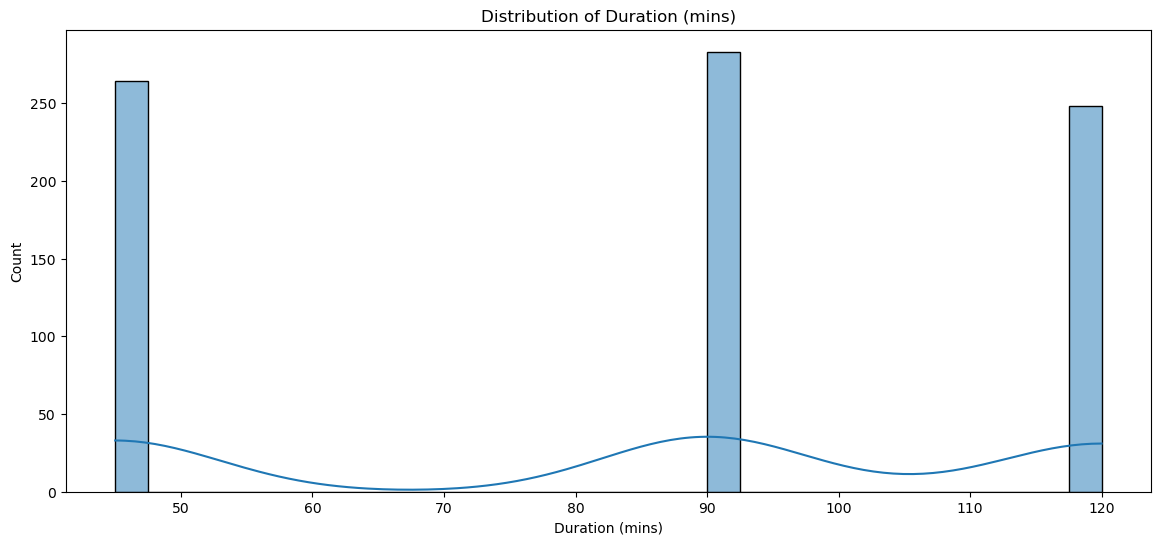

In [268]:
#EDA - Distributions of numerical features/columns
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14, 6))        #figure is the canvas and axes are the actual plot where the figure is plotted, 14width 6 height
sns.histplot(df['Duration (mins)'], bins=30, kde=True)   #kde(kernal density estimate) would differentiate the hist using colors, hue
plt.title("Distribution of Duration (mins)")
plt.show()

C:\Users\Hp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


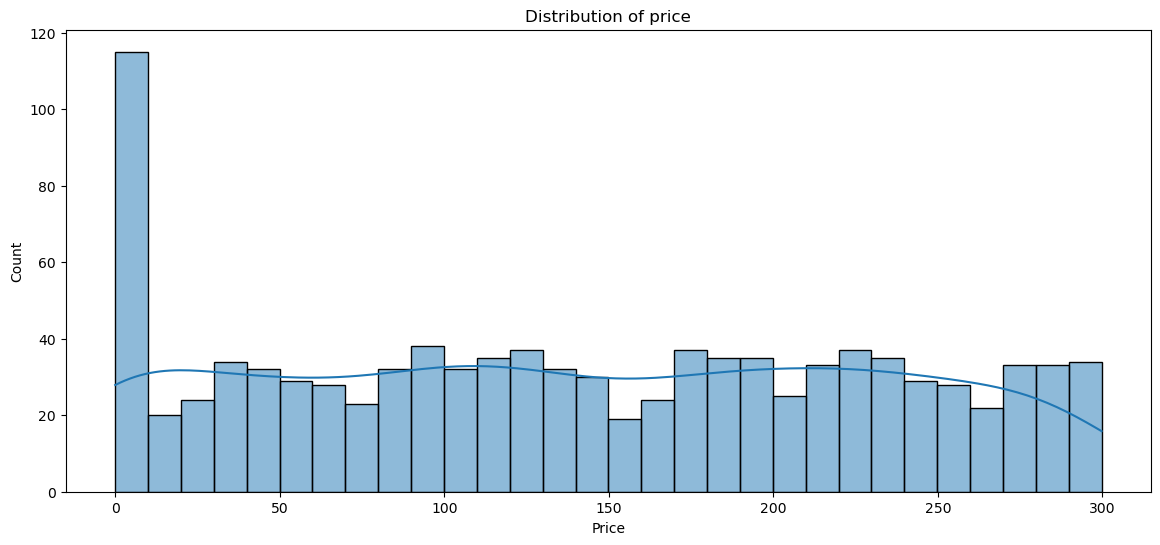

In [269]:
plt.figure(figsize=(14,6))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Distribution of price")
plt.show()

In [270]:
#Here we are converting all the categorical features into numerical features, so that we can calculate the correlation between each feature.
#for col in df1.columns:
 #   if df1[col].dtype== 'object':
  #      print(f"Unique values in {col}:", df1[col].unique)
   #     df1 = df1.apply(pd.to_numeric, errors="coerce") #here if any column is non-numeric then it will forcefully convert it into numerical column
    #    df1.dropna(inplace=True)

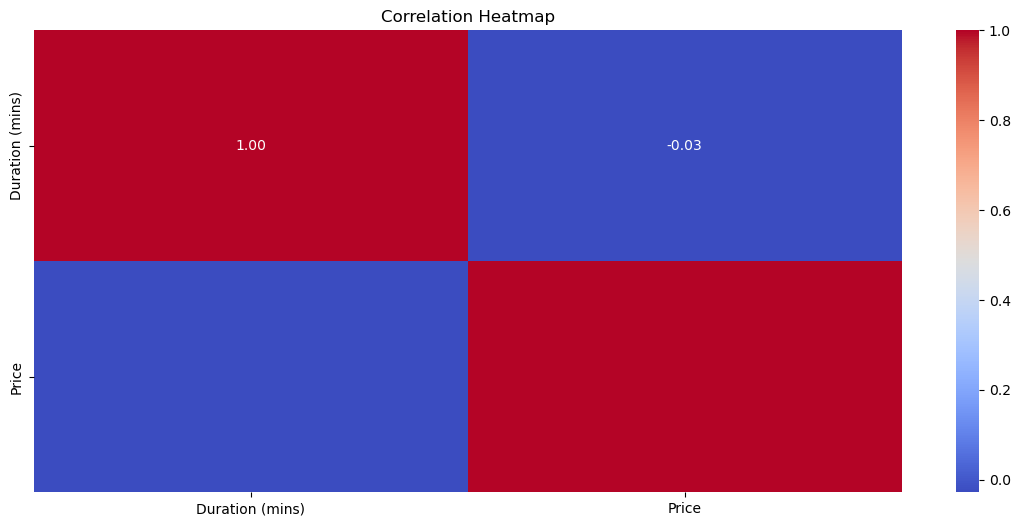

In [274]:
numeric_cols = df1.select_dtypes(include=[np.number])
plt.figure(figsize=(14,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

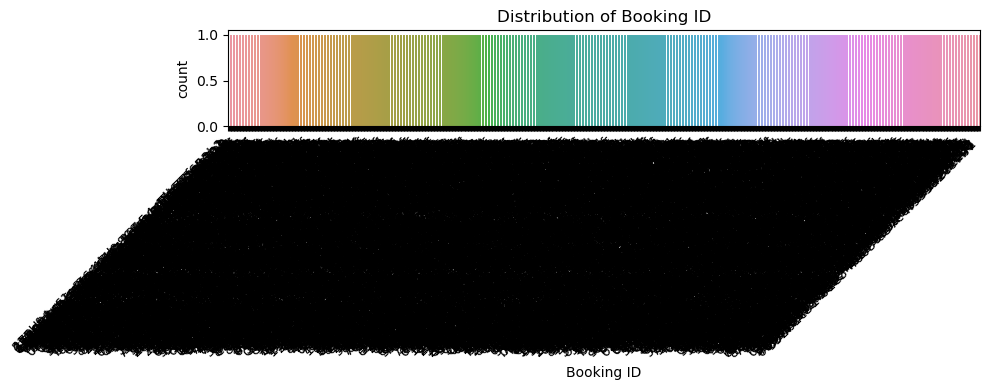

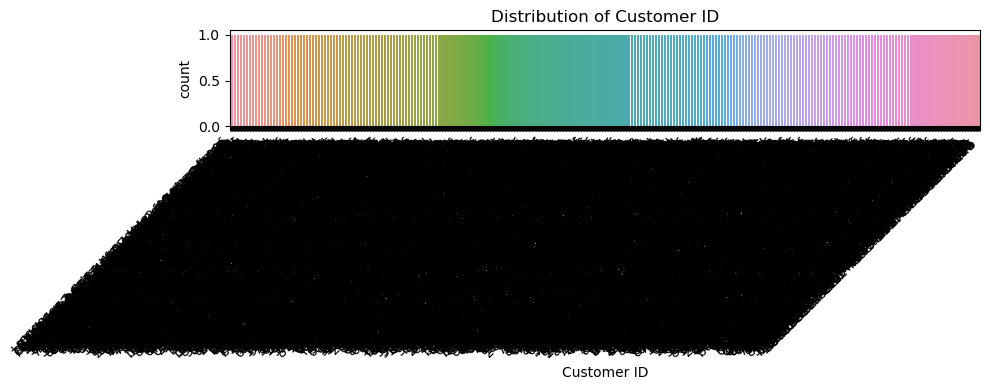

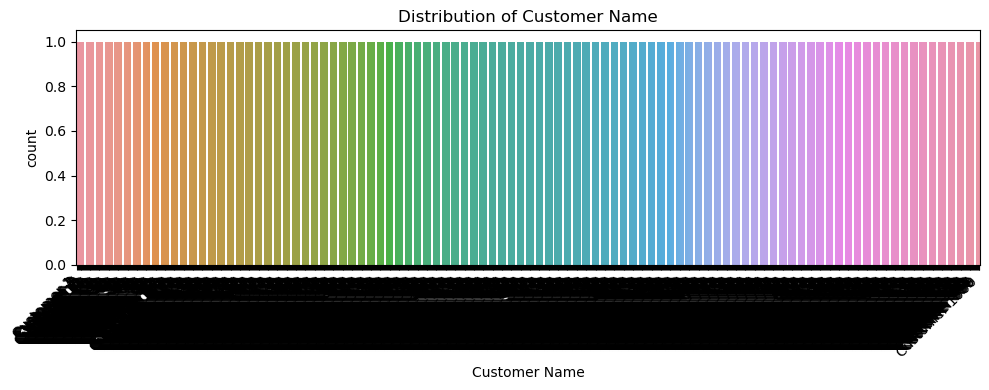

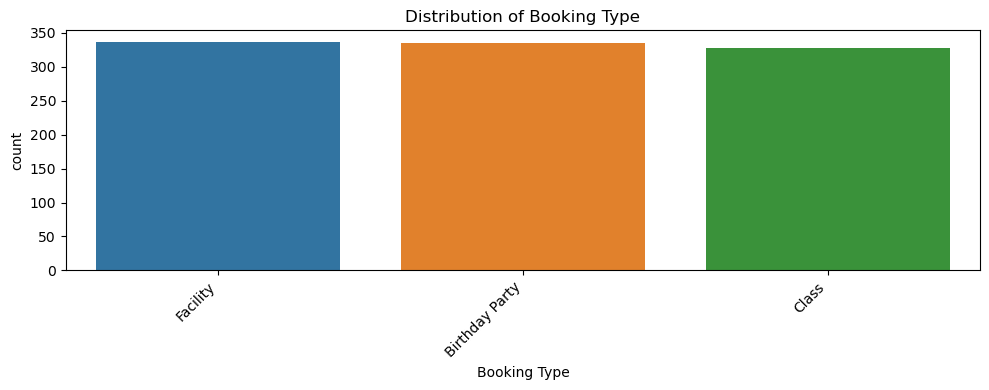

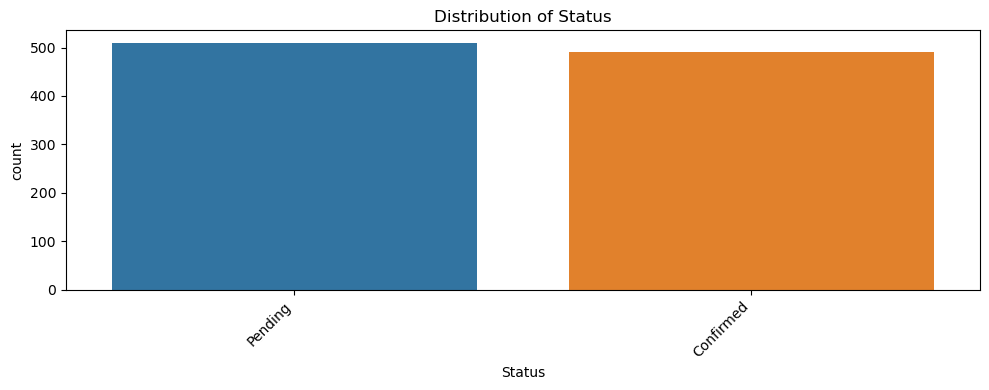

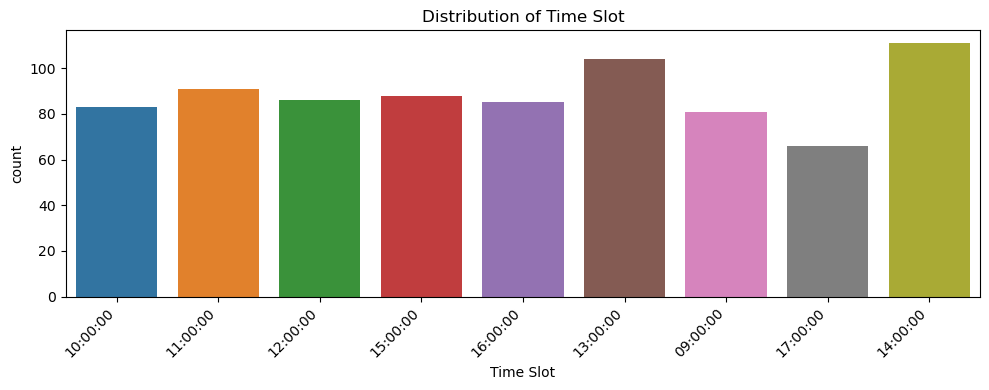

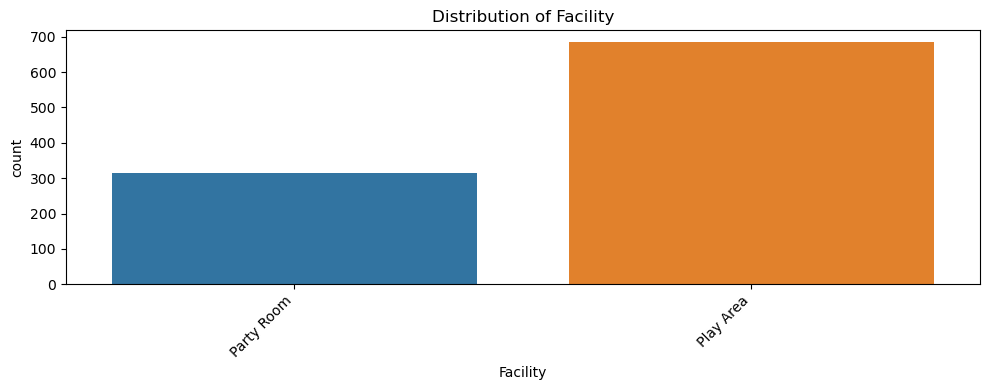

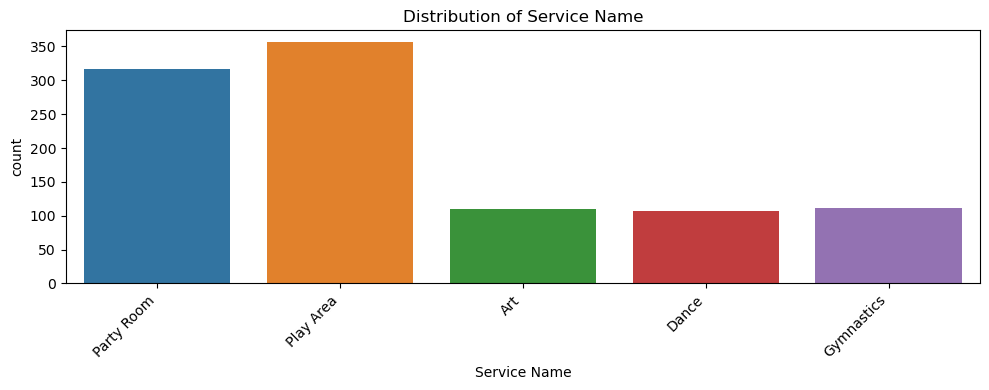

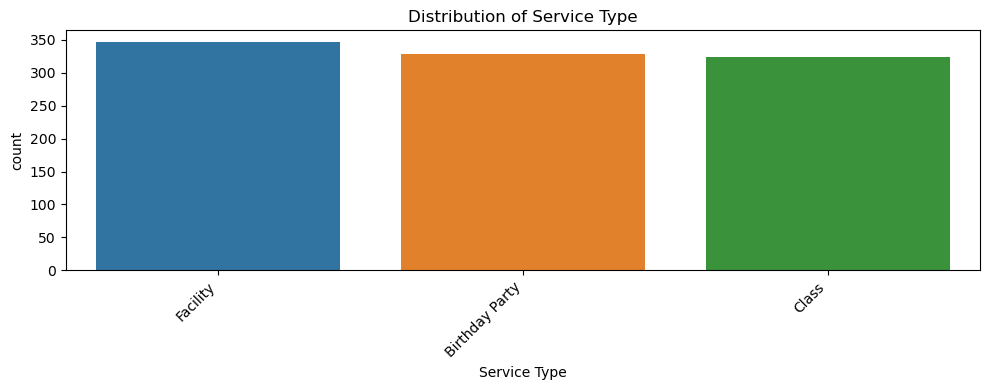

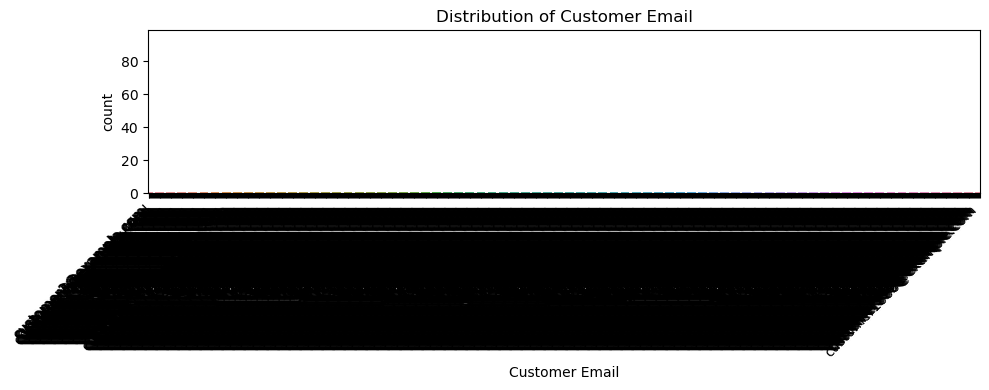

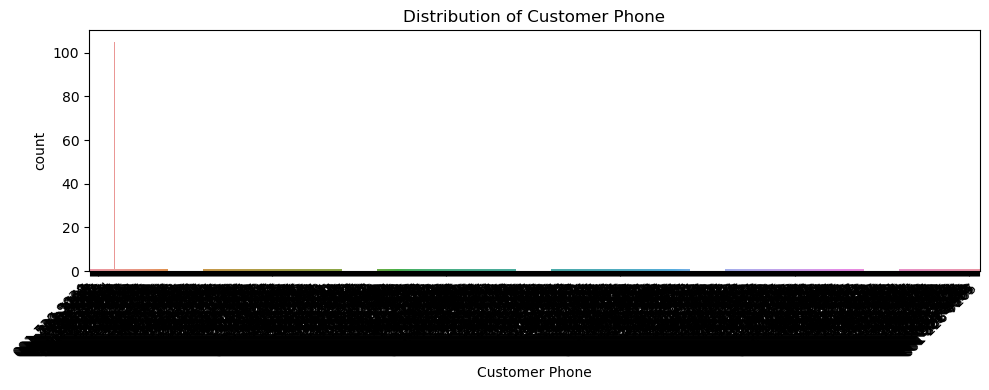

In [275]:
#Categorical variable analysis
#countplot(barplot) is used to show the distribution of categorical variables.
Categorical_cols = df1.select_dtypes(include=["object"]).columns    #selcting categorical features and by .columns, extracting the names of columns
for col in Categorical_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(data=df1, x=col)  #here giving data=df1 because above we are only extracting the column names from categorical_cols, so we need df1(dataframe) to specify countplot, from where exactly we have to take the columns data
    plt.title(f"Distribution of {col}")
    #Here we are rotating the x-axis label to 45 degree to avoid overlapping and using 'ha' (horizontal alignment)to align the x-ais labels to horizontally right
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()    #tight_layout() is used so everything fits within the figure area, maintaing the padding between and aroud the subplots.
    plt.show()

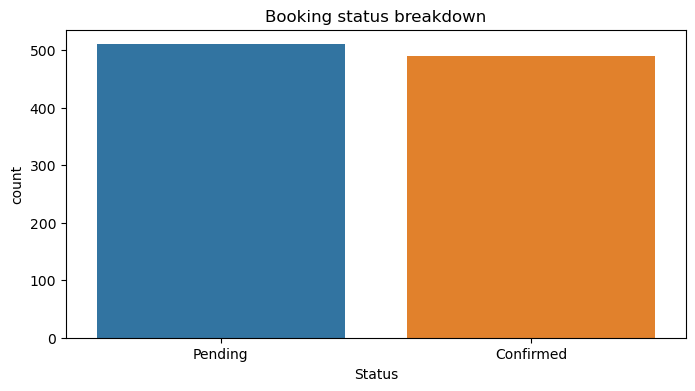

In [276]:
#Booking status breakdown
plt.figure(figsize=(8,4))
sns.countplot(data=df1, x='Status')      #countplot(barplot) which is used to showt the distribution of categorical variables(which means the occurrence of frequency of the particular category.).
plt.title("Booking status breakdown")
plt.show()

In [278]:
#Saving the cleaned dataframe for tablaeu export.
df.to_csv("cleaned1_booking_data.csv", index=False)      